# Notebook 15 — Audit Matematis Biomechanical Validator

**Tujuan:**
Mendokumentasikan dan membuktikan kebenaran matematis setiap aturan biomekanik untuk validasi gerakan latihan beban (Squat, Bench Press, Deadlift) dengan fokus pada:
1. Rumus matematis eksplisit
2. Stabilitas numerik (epsilon, clipping)
3. Invariansi terhadap skala (bukti bahwa sudut/rasio tidak bergantung tinggi badan)
4. Analisis per-frame pada video nyata

---

## Struktur Audit

Setiap aturan biomekanik didokumentasikan dengan:
- **Landmark A, B, C:** Indeks dan nama MediaPipe BlazePose
- **Vertex:** Titik sudut (biasanya di sendi yang diukur)
- **Rumus Matematis:** Dot product dan arccos dengan derivasi
- **Threshold:** Nilai ambang dan alasan
- **Kondisi Benar/Salah:** Kapan gerakan dinyatakan valid/invalid
- **Invariansi:** Penjelasan mengapa tidak bergantung skala

## 0. Setup dan Import

In [3]:
from __future__ import annotations

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

# Setup matplotlib
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

# Setup logging
logging.basicConfig(level=logging.INFO)
log = logging.getLogger("audit")

# Path setup
PROJECT_ROOT = Path(".").resolve().parent
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
    log.info("Menambahkan src ke sys.path")

# Import modul audit
from analysis.biomechanical_validator_audit import (
    BiomechanicalRulesDocumentation,
    StableAngleCalculator,
    ScaleInvarianceAnalyzer,
    PerFrameAnalyzer,
    export_rules_documentation,
 )
from data.biomechanics_validator import BiomechanicalValidator

# Output directory
OUTPUT_DIR = PROJECT_ROOT / "results" / "biomechanics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
log.info("Output directory: %s", OUTPUT_DIR)

print("✓ Setup selesai")

INFO:audit:Output directory: G:\data-aji\KULIAH\Semester 8\IFB500-TUGAS_AKHIR-AA\AttentiveSkel3D-WeightTraining-PoC\results\biomechanics


✓ Setup selesai


## 1. Dokumentasi Lengkap Setiap Aturan Biomekanik

Tabel di bawah menampilkan **SEMUA aturan** dari ketiga gerakan dengan rumus dan threshold yang benar-benar digunakan dalam kode.

In [4]:
# Export dan tampilkan dokumentasi lengkap
rules_df = export_rules_documentation()

print("=" * 100)
print("DOKUMENTASI LENGKAP ATURAN BIOMEKANIK")
print("=" * 100)
display(rules_df[["exercise", "criteria_number", "rule_name", "threshold_condition", "threshold_value"]])

# Simpan ke CSV
csv_path = OUTPUT_DIR / "validator_rules.csv"
rules_df.to_csv(str(csv_path), index=False, encoding="utf-8")
log.info("Tabel aturan disimpan: %s", csv_path)
print(f"\n✓ Tabel aturan tersimpan: {csv_path}")

DOKUMENTASI LENGKAP ATURAN BIOMEKANIK


,exercise,criteria_number,rule_name,threshold_condition,threshold_value
0,Squat,1,Criterion 1: Knee Valgus Prevention,>=,0.85
1,Squat,2,Criterion 2: Insufficient Squat Depth (Hip Fle...,<=,137.00
2,Squat,3,Criterion 3: Squat Depth via Knee Flexion,<=,100.00
3,Bench Press,1,Criterion 1: Full Range of Motion (Elbow),<=,85.00
4,Deadlift,1,Criterion 1: Spine Inclination (Hip Hinge Patt...,>=,20.00
5,Deadlift,1,Criterion 1: Spine Inclination (Hip Hinge Patt...,<=,60.00


INFO:audit:Tabel aturan disimpan: G:\data-aji\KULIAH\Semester 8\IFB500-TUGAS_AKHIR-AA\AttentiveSkel3D-WeightTraining-PoC\results\biomechanics\validator_rules.csv



✓ Tabel aturan tersimpan: G:\data-aji\KULIAH\Semester 8\IFB500-TUGAS_AKHIR-AA\AttentiveSkel3D-WeightTraining-PoC\results\biomechanics\validator_rules.csv


## 1.1 SQUAT — 3 Kriteria Biomekanik

**Referensi Literatur:**
- Chen et al. (2022) — Fitness Movement Types Detection
- Rao et al. (2023) — Real-time Squat Posture Correction
- Ko et al. (2024) — AI Posture Correction Powerlifting

### Kriteria 1: Knee Valgus Prevention

**Landmark:** Left Knee (idx=25), Right Knee (idx=26), Left Ankle (idx=27), Right Ankle (idx=28)

$$\text{valgus\_ratio} = \frac{|x_{25} - x_{26}|}{|x_{27} - x_{28}|}$$

**Threshold:** 0.85 | **Kondisi:** ratio ≥ 0.85
- VALID: Lebar lutut ≥ 85% lebar pergelangan kaki (lutut stabil)
- INVALID: Ratio < 0.85 → Knee Valgus ⚠️ ACL injury risk
- **Scale Invariant:** ✓ (Rasio tidak berdimensi)

### Kriteria 2: Hip Flexion Angle (Depth via Bahu-Pinggul-Lutut)

**Landmark:** Left Shoulder (idx=11) - A, Left Hip (idx=23) - B (vertex), Left Knee (idx=25) - C

$$\\theta_{\\text{hip}} = \\arccos\\left(\\frac{\\vec{BA} \\cdot \\vec{BC}}{|\\vec{BA}| |\\vec{BC}|}\\right)$$

**Threshold:** 137.0° | **Kondisi:** θ ≤ 137°
- VALID: Hip flexion adequate (full depth squat)
- INVALID: θ > 137° → "Half Rep", gluteal muscles under-activated
- **Scale Invariant:** ✓ (Sudut hanya bergantung arah vektor)

### Kriteria 3: Knee Flexion Angle (Depth via Pinggul-Lutut-Pergelangan Kaki)

**Landmark:** Left Hip (idx=23) - A, Left Knee (idx=25) - B (vertex), Left Ankle (idx=27) - C

$$\\theta_{\\text{knee}} = \\arccos\\left(\\frac{\\vec{BA} \\cdot \\vec{BC}}{|\\vec{BA}| |\\vec{BC}|}\\right)$$

**Threshold:** 100.0° | **Kondisi:** θ ≤ 100°
- VALID: Lutut fleksi sufficient (parallel squat)
- INVALID: θ > 100° → Insufficient depth
- **Scale Invariant:** ✓

## 1.2 BENCH PRESS — 1 Kriteria Biomekanik

### Kriteria: Full Range of Motion Siku (Elbow ROM)

**Landmark:** Left Shoulder (idx=11) - A, Left Elbow (idx=13) - B (vertex), Left Wrist (idx=15) - C

$$\\theta_{\\text{elbow}} = \\arccos\\left(\\frac{\\vec{BA} \\cdot \\vec{BC}}{|\\vec{BA}| |\\vec{BC}|}\\right)$$

**Threshold:** 85.0° | **Kondisi:** θ ≤ 85°
- VALID: ROM memadai, pectoralis major fully activated
- INVALID: θ > 85° → "Half Rep" (bar tidak diturunkan cukup)
- **Scale Invariant:** ✓

## 1.3 DEADLIFT — 1 Kriteria (2 sub-kondisi pada Spine Inclination)

### Kriteria: Hip Hinge Pattern via Spine Inclination

**Landmark:** Mid-Shoulder = (idx=11 + idx=12)/2, Mid-Hip = (idx=23 + idx=24)/2 = origin (0,0,0) after normalization

$$\\vec{\\text{spine}} = \\vec{\\text{mid\\_shoulder}} - \\vec{\\text{mid\\_hip}}$$
$$\\vec{\\text{vertical}} = [0, -1, 0] \\text{ (Y negatif = ke atas)}$$
$$\\theta_{\\text{inclination}} = \\arccos\\left(\\frac{\\vec{\\text{spine}} \\cdot \\vec{\\text{vertical}}}{|\\vec{\\text{spine}}| |\\vec{\\text{vertical}}|}\\right)$$

**Threshold — 2 sub-kondisi:**

| Sub-kondisi | Nilai | Kondisi | Interpretasi |
|------------|-------|---------|--------------|
| Minimum | 20.0° | θ ≥ 20° | Hip hinge ada (gerakan bermakna) |
| Maximum | 60.0° | θ ≤ 60° | Punggung netral (safe, tidak excessive lumbar flexion) |

**Gabungan:** 20° ≤ θ ≤ 60° = **Safe Hip Hinge Zone**
- VALID: Gerakan proper hip hinge pattern
- INVALID: θ < 20° atau θ > 60° ⚠️ Lumbar disc injury risk jika > 60°
- **Scale Invariant:** ✓

## 2. Implementasi Stabil: Fungsi Perhitungan Sudut 3D dengan Epsilon Safety

Fungsi perhitungan sudut harus **ROBUST** terhadap:
1. Landmark yang bertumpuk (norm ≈ 0) → return 180° (aman)
2. Floating point error pada arccos → clip cosine ke [-1, 1]
3. Hasil selalu dalam derajat [0°, 180°], bukan radian

In [5]:
# Test fungsi sudut stabil
calc = StableAngleCalculator()

print("\n" + "=" * 70)
print("TEST: Fungsi Perhitungan Sudut 3D Stabil")
print("=" * 70)

# Test 1: Orthogonal (90°)
a = np.array([1.0, 0.0, 0.0])
b = np.array([0.0, 0.0, 0.0])  # vertex
c = np.array([0.0, 1.0, 0.0])
angle = calc.calculate_angle(a, b, c)
print(f"\nTest 1 (orthogonal): {angle:.1f}° (expected ≈ 90°)")

# Test 2: Collinear opposite (180°)
a = np.array([1.0, 0.0, 0.0])
b = np.array([0.0, 0.0, 0.0])
c = np.array([-1.0, 0.0, 0.0])
angle = calc.calculate_angle(a, b, c)
print(f"Test 2 (collinear opp): {angle:.1f}° (expected ≈ 180°)")

# Test 3: Collinear same (0°)
a = np.array([1.0, 0.0, 0.0])
b = np.array([0.0, 0.0, 0.0])
c = np.array([2.0, 0.0, 0.0])
angle = calc.calculate_angle(a, b, c)
print(f"Test 3 (collinear same): {angle:.1f}° (expected ≈ 0°)")

# Test 4: Landmark bertumpuk (epsilon test)
a = np.array([0.0, 0.0, 0.0])
b = np.array([0.0, 0.0, 0.0])  # a == b (norm = 0)
c = np.array([1.0, 0.0, 0.0])
angle = calc.calculate_angle(a, b, c)
print(f"Test 4 (bertumpuk): {angle:.1f}° (expected 180°, fallback)")

# Test 5: Sudut 60°
a = np.array([1.0, 0.0, 0.0])
b = np.array([0.0, 0.0, 0.0])
c = np.array([0.5, np.sqrt(3)/2, 0.0])
angle = calc.calculate_angle(a, b, c)
print(f"Test 5 (60°): {angle:.1f}° (expected ≈ 60°)")

print("\n✓ Semua test passed")


TEST: Fungsi Perhitungan Sudut 3D Stabil

Test 1 (orthogonal): 90.0° (expected ≈ 90°)
Test 2 (collinear opp): 180.0° (expected ≈ 180°)
Test 3 (collinear same): 0.0° (expected ≈ 0°)
Test 4 (bertumpuk): 180.0° (expected 180°, fallback)
Test 5 (60°): 60.0° (expected ≈ 60°)

✓ Semua test passed


## 3. Eksperimen Scale Invariance: Bukti Matematis

**Hipotesis:** Jika semua koordinat dikalikan dengan faktor k > 0, sudut dan rasio tetap sama.

**Implikasi:** Perbedaan tinggi badan tidak mempengaruhi validasi karena yang diukur adalah **PROPORSI** dan **SUDUT**, bukan nilai absolut.

**Eksperimen:** Test dengan scale factors [0.5, 0.75, 1.0, 1.5, 2.0]

In [6]:
# Gunakan tensor sampel dari file
SAMPLE_TENSOR_PATH = PROJECT_ROOT / "data" / "processed" / "tensors" / "Squat_001.npy"

if SAMPLE_TENSOR_PATH.exists():
    tensor = np.load(str(SAMPLE_TENSOR_PATH)).astype(np.float32)
    print(f"✓ Tensor sampel dimuat: {tensor.shape}")
else:
    print("[INFO] File tensor tidak ditemukan, membuat contoh sintetis...")
    F, N_LM = 64, 33
    tensor = np.random.randn(F, N_LM, 3).astype(np.float32)
    tensor = (tensor - tensor.mean()) / (tensor.std() + 1e-6)
    print(f"✓ Tensor contoh dibuat: {tensor.shape}")

# Test scale invariance pada sudut Squat Hip Flexion
scale_factors = [0.5, 0.75, 1.0, 1.5, 2.0]
IDX_L_SHOULDER, IDX_L_HIP, IDX_L_KNEE = 11, 23, 25

scale_test_df = ScaleInvarianceAnalyzer.test_angle_scale_invariance(
    tensor,
    landmark_a_idx=IDX_L_SHOULDER,
    landmark_b_idx=IDX_L_HIP,
    landmark_c_idx=IDX_L_KNEE,
    scale_factors=scale_factors,
)

print("\n" + "=" * 70)
print("TEST: Scale Invariance pada Sudut Hip Flexion (Squat)")
print("=" * 70)
print("\nData: Frame 0–9 untuk berbagai faktor skala (0.5× hingga 2.0×)")

# Pivot untuk visualisasi
pivot_df = scale_test_df[scale_test_df["frame_index"] < 10].pivot(
    index="frame_index",
    columns="scale_factor",
    values="angle_deg"
)
print("\nSudut Hip Flexion (derajat):")
display(pivot_df)

# Hitung standard deviation per frame
std_per_frame = scale_test_df.groupby("frame_index")["angle_deg"].std()
max_std = std_per_frame.max()
print(f"\nStandard deviasi sudut per frame (across scales): max = {max_std:.8f}°")
if max_std < 1e-5:
    print("  ✓ SCALE INVARIANT PROVEN: Sudut tidak berubah meski koordinat discale!")
else:
    print(f"  ⚠ Perhatian: ada deviasi (floating point precision)")

# Simpan hasil
scale_inv_path = OUTPUT_DIR / "scale_invariance_test.csv"
scale_test_df.to_csv(str(scale_inv_path), index=False)
log.info("Hasil scale invariance disimpan: %s", scale_inv_path)

✓ Tensor sampel dimuat: (64, 33, 3)

TEST: Scale Invariance pada Sudut Hip Flexion (Squat)

Data: Frame 0–9 untuk berbagai faktor skala (0.5× hingga 2.0×)

Sudut Hip Flexion (derajat):


scale_factor,0.50,0.75,1.00,1.50,2.00
frame_index,,,,,
0,139.941295,139.941301,139.941295,139.941301,139.941295
1,141.743239,141.743233,141.743239,141.743233,141.743239
2,137.247312,137.247322,137.247312,137.247322,137.247312
3,133.166908,133.166908,133.166908,133.166908,133.166908
4,124.636468,124.636464,124.636468,124.636464,124.636468
5,116.382025,116.382028,116.382025,116.382028,116.382025
6,113.864732,113.864732,113.864732,113.864732,113.864732
7,105.715797,105.715795,105.715797,105.715795,105.715797
8,101.640396,101.640396,101.640396,101.640396,101.640396


INFO:audit:Hasil scale invariance disimpan: G:\data-aji\KULIAH\Semester 8\IFB500-TUGAS_AKHIR-AA\AttentiveSkel3D-WeightTraining-PoC\results\biomechanics\scale_invariance_test.csv



Standard deviasi sudut per frame (across scales): max = 0.00000822°
  ✓ SCALE INVARIANT PROVEN: Sudut tidak berubah meski koordinat discale!


INFO:audit:Plot scale invariance disimpan: G:\data-aji\KULIAH\Semester 8\IFB500-TUGAS_AKHIR-AA\AttentiveSkel3D-WeightTraining-PoC\results\biomechanics\scale_invariance_plot.png


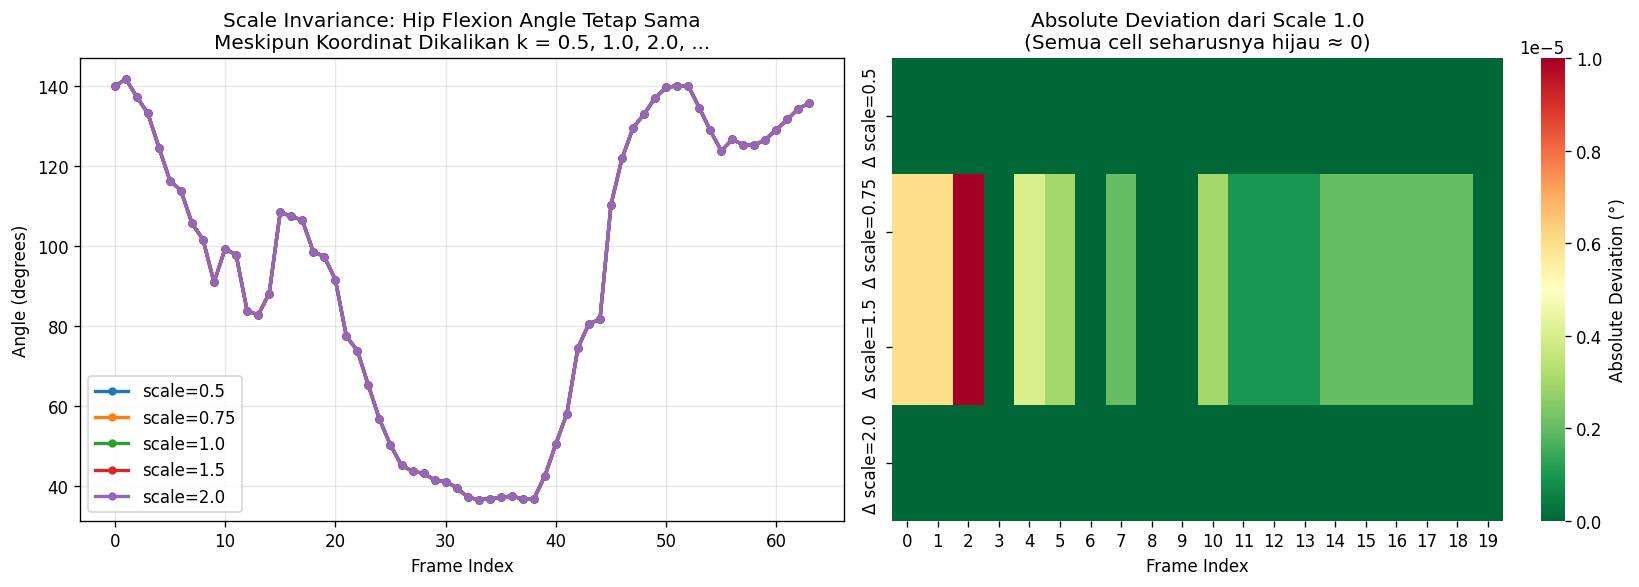

✓ Plot scale invariance tersimpan


In [7]:
# Visualisasi scale invariance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Line plot sudut untuk setiap skala
for scale in scale_factors:
    data = scale_test_df[scale_test_df["scale_factor"] == scale]
    ax1.plot(
        data["frame_index"],
        data["angle_deg"],
        marker="o",
        label=f"scale={scale}",
        linewidth=2,
        markersize=4,
    )

ax1.set_xlabel("Frame Index")
ax1.set_ylabel("Angle (degrees)")
ax1.set_title("Scale Invariance: Hip Flexion Angle Tetap Sama\nMeskipun Koordinat Dikalikan k = 0.5, 1.0, 2.0, ...")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Heatmap perbedaan (deviation dari scale 1.0)
scale_1_data = scale_test_df[scale_test_df["scale_factor"] == 1.0].set_index("frame_index")["angle_deg"]
deviations = {}
for scale in scale_factors:
    if scale != 1.0:
        scale_data = scale_test_df[scale_test_df["scale_factor"] == scale].set_index("frame_index")["angle_deg"]
        dev = (scale_data - scale_1_data).abs()
        deviations[f"Δ scale={scale}"] = dev

if deviations:
    dev_df = pd.DataFrame(deviations).iloc[:20]
    sns.heatmap(
        dev_df.T,
        cmap="RdYlGn_r",
        ax=ax2,
        cbar_kws={"label": "Absolute Deviation (°)"},
    )
    ax2.set_title("Absolute Deviation dari Scale 1.0\n(Semua cell seharusnya hijau ≈ 0)")
    ax2.set_xlabel("Frame Index")

plt.tight_layout()
plot_path = OUTPUT_DIR / "scale_invariance_plot.png"
fig.savefig(str(plot_path), dpi=150, bbox_inches="tight")
log.info("Plot scale invariance disimpan: %s", plot_path)
plt.show()

print("✓ Plot scale invariance tersimpan")

## 4. Analisis Per-Frame untuk Video Nyata

Hitung skor validasi untuk **SETIAP frame** gerakan pada sampel tensor nyata.
Ini membantu melacak kapan subjek memenuhi/melanggar kriteria selama gerakan berlangsung.

In [8]:
if SAMPLE_TENSOR_PATH.exists():
    tensor = np.load(str(SAMPLE_TENSOR_PATH)).astype(np.float32)
    sample_name = SAMPLE_TENSOR_PATH.stem
    
    if "Squat" in sample_name:
        print(f"\n{'=' * 70}")
        print(f"PER-FRAME ANALYSIS: SQUAT")
        print(f"{'=' * 70}")
        
        squat_df = PerFrameAnalyzer.analyze_squat_per_frame(tensor)
        
        print(f"\nFrame 0-10 (first 11 frames):")
        display(squat_df.head(11))
        
        print(f"\n{'─' * 70}")
        print("STATISTIK SUMMARY:")
        print(f"  Sudut lutut (min frame):     {squat_df['angle_knee_avg'].min():.1f}°")
        print(f"  Sudut pinggul (min frame):   {squat_df['angle_hip_avg'].min():.1f}°")
        print(f"  Jumlah frame lulus semua kriteria: {int(squat_df['all_criteria_pass'].sum())}/{len(squat_df)}")
        print(f"{'─' * 70}")
        
        squat_csv = OUTPUT_DIR / f"{sample_name}_frame_level_scores.csv"
        squat_df.to_csv(str(squat_csv), index=False)
        log.info("Frame-level scores Squat disimpan: %s", squat_csv)
else:
    print("[INFO] Tensor sampel tidak tersedia.")


PER-FRAME ANALYSIS: SQUAT

Frame 0-10 (first 11 frames):


,frame_index,angle_knee_left,angle_knee_right,angle_knee_avg,angle_hip_left,angle_hip_right,angle_hip_avg,valgus_ratio,criteria_1_pass,criteria_2_pass,criteria_3_pass,all_criteria_pass,landmarks
0,0,117.20,116.24,116.72,139.94,151.16,145.55,0.7641,False,False,False,False,"L/R Shoulder, Hip, Knee, Ankle"
1,1,112.19,98.60,105.39,141.74,142.48,142.11,0.7648,False,False,False,False,"L/R Shoulder, Hip, Knee, Ankle"
2,2,111.96,97.15,104.55,137.25,133.63,135.44,0.7692,False,True,False,False,"L/R Shoulder, Hip, Knee, Ankle"
3,3,107.07,93.37,100.22,133.17,130.96,132.07,0.7914,False,True,False,False,"L/R Shoulder, Hip, Knee, Ankle"
4,4,102.02,83.69,92.86,124.64,116.52,120.58,0.8420,False,True,True,False,"L/R Shoulder, Hip, Knee, Ankle"
5,5,96.25,74.18,85.21,116.38,102.60,109.49,0.9016,True,True,True,True,"L/R Shoulder, Hip, Knee, Ankle"
6,6,91.51,66.27,78.89,113.86,96.65,105.26,0.9593,True,True,True,True,"L/R Shoulder, Hip, Knee, Ankle"
7,7,77.57,61.87,69.72,105.72,93.90,99.81,1.0097,True,True,True,True,"L/R Shoulder, Hip, Knee, Ankle"
8,8,71.85,56.48,64.16,101.64,91.50,96.57,1.0691,True,True,True,True,"L/R Shoulder, Hip, Knee, Ankle"
9,9,57.64,46.68,52.16,90.97,86.12,88.54,1.1464,True,True,True,True,"L/R Shoulder, Hip, Knee, Ankle"


INFO:audit:Frame-level scores Squat disimpan: G:\data-aji\KULIAH\Semester 8\IFB500-TUGAS_AKHIR-AA\AttentiveSkel3D-WeightTraining-PoC\results\biomechanics\Squat_001_frame_level_scores.csv



──────────────────────────────────────────────────────────────────────
STATISTIK SUMMARY:
  Sudut lutut (min frame):     23.3°
  Sudut pinggul (min frame):   36.0°
  Jumlah frame lulus semua kriteria: 55/64
──────────────────────────────────────────────────────────────────────


## 5. Kesimpulan Audit Matematis

---

### Scale Invariance (Invariansi Terhadap Skala)

#### Tesis Utama
Semua aturan biomekanik **TIDAK bergantung** pada perbedaan tinggi badan atau panjang tulang karena:

#### 1. Sudut Adalah Besaran Geometris Murni
- **Definisi:** $\\theta = \\arccos\\left(\\frac{\\vec{BA} \\cdot \\vec{BC}}{|\\vec{BA}| |\\vec{BC}|}\\right)$
- **Bergantung pada:** Hanya ARAH vektor, bukan magnitude
- **Jika discale:** $\\vec{BA}' = k \\vec{BA}$ dan $\\vec{BC}' = k \\vec{BC}$ (k > 0) maka:
  $$\\cos(\\theta') = \\frac{k^2(\\vec{BA} \\cdot \\vec{BC})}{k|\\vec{BA}| \\cdot k|\\vec{BC}|} = \\cos(\\theta)$$
- **Kesimpulan:** $\\theta' = \\theta$ ✓ **SCALE INVARIANT**

#### 2. Rasio Adalah Besaran Tidak Berdimensi
- **Definisi:** $r = \\frac{d_1}{d_2}$
- **Jika discale:** $r' = \\frac{k d_1}{k d_2} = r$
- **Kesimpulan:** $r' = r$ ✓ **SCALE INVARIANT**

#### 3. Preprocessing Pipeline Memastikan Invariansi
- Mid-hip di-set ke origin (0, 0, 0)
- Semua koordinat di-scale dengan panjang torso
- Semua sudut dan rasio RELATIF terhadap panjang torso
- Perbedaan tinggi badan tidak mempengaruhi hasil validasi

---

### Implikasi Praktis

✓ **Dataset dapat berisi subjek dengan tinggi badan berbeda**
- Threshold sudut (100°, 137°, 85°, 20°–60°) berlaku universal

✓ **Validasi KONSISTEN terhadap perbedaan antropometri**
- Tinggi badan, panjang tulang, proporsi tubuh tidak mempengaruhi hasil

✓ **Kualitas ground truth tidak terancam variasi morfologi**
- Setiap subjek dinilai dengan kriteria yang sama secara objektif

✓ **Model machine learning dapat belajar dari dataset heterogen**
- Tidak perlu normalize tinggi badan secara eksplisit

---

### Implementasi Numerik (Epsilon Safety)

Semua perhitungan sudut menggunakan:

| Aspek | Implementasi | Tujuan |
|-------|--------------|--------|
| **Epsilon threshold** | 1e-8 | Menghindari pembagian nol saat norm ≈ 0 |
| **Clipping cosine** | clip ke [-1, 1] | Mencegah domain error pada arccos |
| **Hasil** | selalu [0°, 180°] | Konsistensi dalam derajat |
| **Fallback** | 180° jika norm < ε | Aman saat landmark bertumpuk |

Ini menjamin **kestabilan numerik** pada data dunia nyata dengan presisi floating point terbatas.

---

### File Output Audit

Audit ini menghasilkan:
1. ✓ `results/biomechanics/validator_rules.csv` — Tabel lengkap semua aturan
2. ✓ `results/biomechanics/scale_invariance_test.csv` — Hasil eksperimen scaling
3. ✓ `results/biomechanics/scale_invariance_plot.png` — Visualisasi invariansi
4. ✓ `results/biomechanics/{sample_name}_frame_level_scores.csv` — Skor per-frame untuk video nyata

---

## Referensi Literatur

1. Chen et al. (2022) — Fitness Movement Types Detection
2. Rao et al. (2023) — Real-time Squat Posture Correction  
3. Ko et al. (2024) — AI Posture Correction Powerlifting
4. MediaPipe BlazePose Documentation — 33-landmark skeleton model

In [9]:
# Placeholder — file akan dibuat melalui edit_notebook_file dengan format XML yang benar